In [9]:
import pandas as pd

In [10]:
df = pd.read_csv("Housing(1).csv")
df

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished
541,1767150,2400,3,1,1,no,no,no,no,no,0,no,semi-furnished
542,1750000,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished
543,1750000,2910,3,1,1,no,no,no,no,no,0,no,furnished


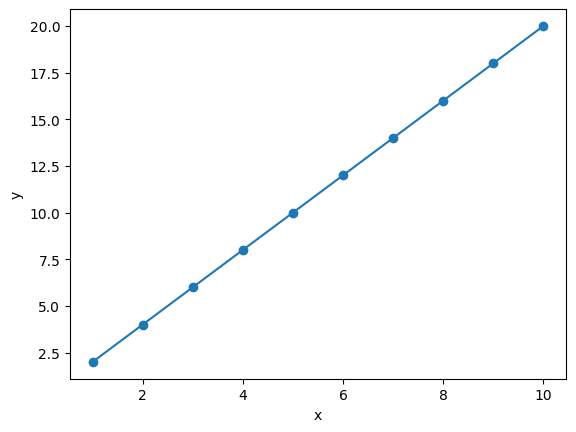

Regression Coefficients:  2.0  and  0.0
p-value=  4.375000000000076e-80
R2 Score=  1.0
Standard Error=  0.0
Equation of line:
y= 2.0 x + 0.0 + 0.0
For x=11, y= 22.0


In [11]:
import matplotlib.pyplot as plt
from scipy import stats
x = [1,2,3,4,5,6,7,8,9,10]
y = [2,4,6,8,10,12,14,16,18,20]
slope, intercept, r, p, std_err = stats.linregress(x, y)
def myfunc(x):
    return slope * x + intercept
mymodel = list(map(myfunc, x))
plt.scatter(x, y)
plt.plot(x, mymodel)
plt.xlabel("x")
plt.ylabel("y")
plt.show()
print("Regression Coefficients: ", slope, " and ", intercept)
print("p-value= ",p)
print("R2 Score= ",r)
print("Standard Error= ",std_err)
print("Equation of line:")
print("y=",round(slope,2),"x","+",round(intercept,2),"+",round(std_err,0))
print("For x=11, y=",myfunc(11))

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [13]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


<Axes: >

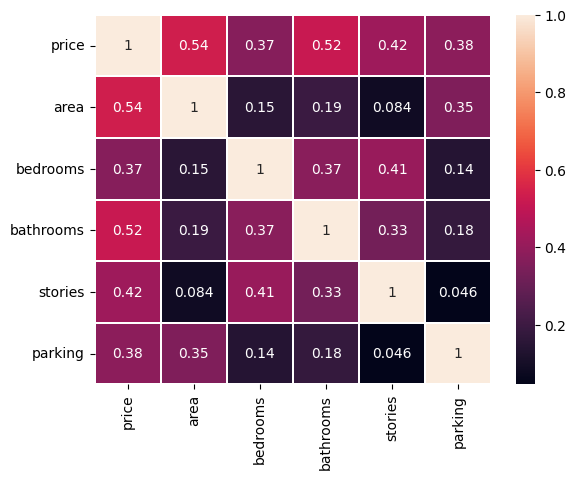

In [15]:
import seaborn as sns
sns.heatmap(data=df.corr(numeric_only=True), annot=True, linecolor='white', linewidths=0.25)

In [17]:
y=df[['price']]
X=df[['area']]
y

,price
0,13300000
1,12250000
2,12250000
3,12215000
4,11410000
...,...
540,1820000
541,1767150
542,1750000
543,1750000


In [19]:
X

,area
0,7420
1,8960
2,9960
3,7500
4,7420
...,...
540,3000
541,2400
542,3620
543,2910


In [20]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train,y_test = train_test_split(X,y,random_state=42,train_size=0.25)

In [21]:
X_test

,area
316,5900
77,6500
360,4040
90,5000
493,3960
...,...
100,6600
226,5170
508,4400
213,4995


In [23]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
reg = LinearRegression().fit(X_train, y_train)
print("Regression Coefficient=",reg.coef_)
print("Regression Intercept=",reg.intercept_)
print("Mean Absolute Error=",mean_absolute_error(y_train, reg.predict(X_train)))
print("Mean Squared Error=",mean_squared_error(y_train, reg.predict(X_train)))
print("Root Mean Squared Error=",np.sqrt(mean_squared_error(y_train, reg.predict(X_train))))
print("R2 Score=",reg.score(X_train, y_train))

Regression Coefficient= [[561.59788688]]
Regression Intercept= [1991243.71928215]
Mean Absolute Error= 1094781.6758043026
Mean Squared Error= 2190153135309.3308
Root Mean Squared Error= 1479916.597416669
R2 Score= 0.35156735322144284


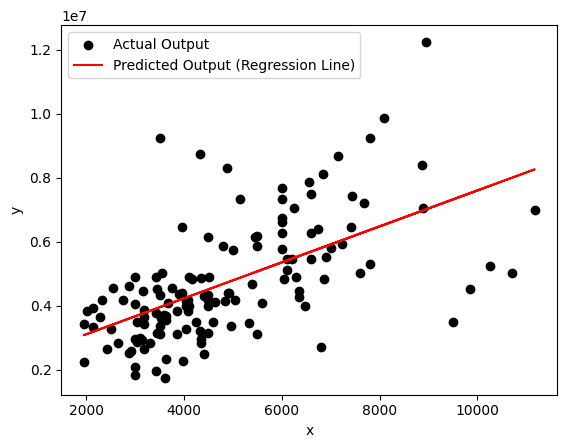

In [24]:
plt.scatter(X_train, y_train,color='black')
plt.plot(X_train, reg.predict(X_train),color='red')
plt.xlabel("x")
plt.ylabel("y")
plt.legend(["Actual Output", "Predicted Output (Regression Line)"], loc="upper left")
plt.show()

Actual Output= [14, 22, 24, 32, 36, 41, 44, 52]
Predicted Output= [15.16666667 20.29761905 25.42857143 30.55952381 35.69047619 40.82142857
 45.95238095 51.08333333]
Regression Coefficient= [5.13095238]
Regression Intercept= 10.035714285714281
Mean Absolute Error= 1.1369047619047623
Mean Squared Error= 1.6443452380952412
Root Mean Squared Error= 1.2823202556675306
R2 Score= 0.9882428672507994


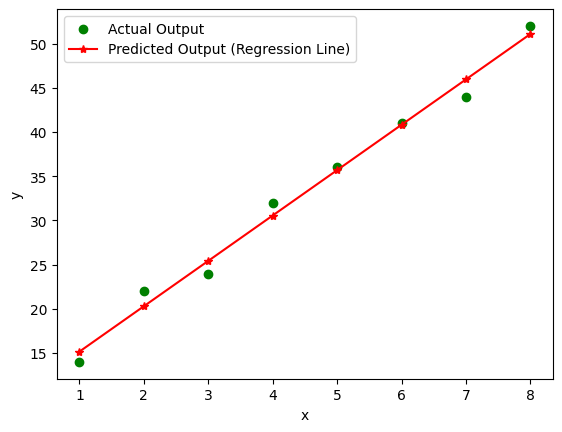

In [26]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
X=[[1],[2],[3],[4],[5],[6],[7],[8]]
y=[14,22,24,32,36,41,44,52]
reg = LinearRegression().fit(X, y)
print("Actual Output=",y)
print("Predicted Output=",reg.predict(X))
print("Regression Coefficient=",reg.coef_)
print("Regression Intercept=",reg.intercept_)
print("Mean Absolute Error=",mean_absolute_error(y, reg.predict(X)))
print("Mean Squared Error=",mean_squared_error(y, reg.predict(X)))
print("Root Mean Squared Error=",np.sqrt(mean_squared_error(y, reg.predict(X))))
print("R2 Score=",reg.score(X, y))
plt.scatter(X, y,color='green')
plt.plot(X, reg.predict(X),color='red', marker='*')
plt.xlabel("x")
plt.ylabel("y")
plt.legend(["Actual Output", "Predicted Output (Regression Line)"], loc="upper left")
plt.show()